# 02 · Monte Carlo, from scratch / 手刻蒙地卡羅

This notebook derives the confidence band **without** touching chi-squared. Everything is just: draw white noise, run EMD, repeat, take percentiles.

本 notebook 不碰卡方分佈，完全靠蒙地卡羅：產生白雜訊 → 跑 EMD → 反覆 → 取百分位數。

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EMD

from emdsig import compute_et, plot_significance

rng = np.random.default_rng(0)

## 1. One white-noise realisation / 一次白雜訊實驗

First, check the Wu-Huang claim on a single realisation: ln(E) vs ln(T) should have slope -1.

In [2]:
N = 2048
one_draw = rng.standard_normal(N)
imfs = EMD().emd(one_draw)
E, T = compute_et(imfs)
valid = ~np.isnan(T)
lnE, lnT = np.log(E[valid]), np.log(T[valid])

slope, intercept = np.polyfit(lnT, lnE, 1)
print(f'empirical slope: {slope:.3f}  (theory: -1)')

empirical slope: -0.853  (theory: -1)


## 2. Manual Monte Carlo loop / 手刻 Monte Carlo 迴圈

In [3]:
M = 60          # keep tiny for speed; 100+ in practice
all_lnT, all_lnE = [], []

for i in range(M):
    sample = rng.standard_normal(N)
    imfs_i = EMD().emd(sample)
    Ei, Ti = compute_et(imfs_i)
    mask = ~np.isnan(Ti)
    all_lnT.append(np.log(Ti[mask]))
    all_lnE.append(np.log(Ei[mask]))

print(f'collected {M} noise realisations')

collected 60 noise realisations


## 3. Aggregate and take percentiles / 聚合並取百分位數

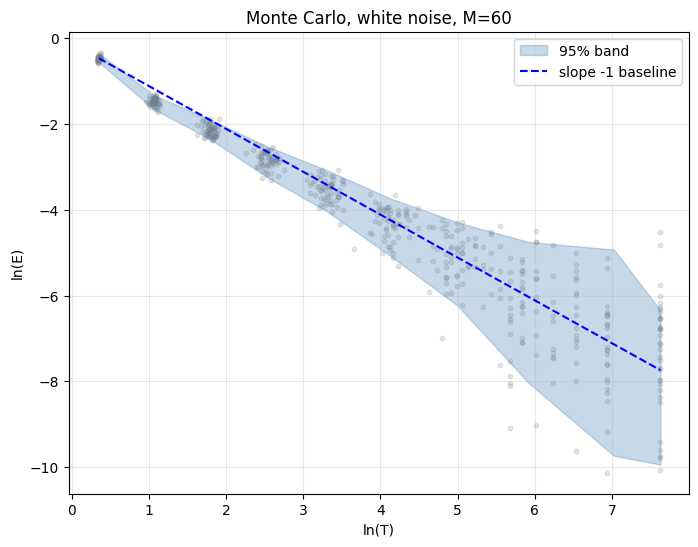

In [4]:
max_k = max(len(a) for a in all_lnT)
lnT_mat = np.full((M, max_k), np.nan)
lnE_mat = np.full((M, max_k), np.nan)
for i, (t, e) in enumerate(zip(all_lnT, all_lnE)):
    lnT_mat[i, :len(t)] = t
    lnE_mat[i, :len(e)] = e

grid = np.nanmean(lnT_mat, axis=0)
lo = np.nanpercentile(lnE_mat, 2.5,  axis=0)
hi = np.nanpercentile(lnE_mat, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(8, 6))
for i in range(M):
    ax.scatter(lnT_mat[i], lnE_mat[i], color='gray', alpha=0.2, s=10)
order = np.argsort(grid)
ax.fill_between(grid[order], lo[order], hi[order], color='steelblue', alpha=0.3, label='95% band')
ax.plot(grid[order], -grid[order] + (lnE_mat[:, 0].mean() + grid[0]), 'b--', label='slope -1 baseline')
ax.set_xlabel('ln(T)'); ax.set_ylabel('ln(E)')
ax.set_title(f'Monte Carlo, white noise, M={M}')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

## 4. Why this matters / 為什麼重要

Once you own the loop, swapping `rng.standard_normal(N)` with `generate_fgn(N, H)` gives you a **coloured-noise** baseline in one line. Closed-form chi-squared cannot do that.

一旦你擁有這個迴圈，把 `rng.standard_normal(N)` 換成 `generate_fgn(N, H)` 就能得到**有色雜訊**基準——一行就搞定。閉式卡方做不到這點。

In [5]:
from emdsig import monte_carlo_bounds

grid2, lo2, hi2 = monte_carlo_bounds(
    N=N, n_trials=60, noise='white', seed=0,
)
print('Library call matches the manual loop (up to sampling noise).')

Library call matches the manual loop (up to sampling noise).
